In [5]:
# MoPhones Credit Analysis
# Author: Kibet Ronald

In [6]:
!pip install --upgrade openpyxl

Requirement already up-to-date: openpyxl in c:\users\user\anaconda3\envs\learn-env\lib\site-packages (3.1.5)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [8]:

os.getcwd()

'C:\\Users\\User\\Downloads\\morphone'

In [9]:


os.listdir(r"D:\Downloads\Credit Data")

['Credit Data']

In [10]:
import zipfile

credit_zip = r"D:\Downloads\Credit Data.zip"

with zipfile.ZipFile(credit_zip, 'r') as zip_ref:
    zip_ref.extractall("credit_data")

In [11]:


os.listdir("credit_data")

['Credit Data']

In [12]:
# credit data

os.listdir("credit_data/Credit Data")


['Credit Data - 01-01-2025.csv',
 'Credit Data - 30-03-2025.csv',
 'Credit Data - 30-06-2025.csv',
 'Credit Data - 30-09-2025.csv',
 'Credit Data - 30-12-2025.csv',
 'Credit Data Definitions.xlsx']

In [13]:
folder_path = r"credit_data/Credit Data"

definitions_path = os.path.join(folder_path, "Credit Data Definitions.xlsx")

In [14]:
definitions = pd.read_excel(definitions_path, engine="openpyxl")

In [15]:
definitions.columns
definitions.head(20)

,Column Name,Definition
0,LOAN_ID,Unique identifier for the loan.
1,DATE,Reporting (snapshot) date on which all loan me...
2,CUSTOMER_AGE,Number of days since the loan sale date (SALE_...
3,TOTAL_PAID,Cumulative amount paid by the customer up to t...
4,TOTAL_DUE_TODAY,Total amount the customer is expected to have ...
5,BALANCE,Outstanding loan balance after accounting for ...
6,DAYS_PAST_DUE,Number of days the customer is behind on payme...
7,CLOSING_BALANCE,Final balance for reporting; set to zero if th...
8,ADVANCE,Amount the customer has paid ahead of schedule...
9,BALANCE_DUE_TO_DATE,Net payment position of the customer; positive...


In [16]:
folder_path = r"credit_data/Credit Data" 

In [17]:
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
print(files)

['Credit Data - 01-01-2025.csv', 'Credit Data - 30-03-2025.csv', 'Credit Data - 30-06-2025.csv', 'Credit Data - 30-09-2025.csv', 'Credit Data - 30-12-2025.csv']


In [ ]:
#credit_data

In [18]:
df_list = []

for file in files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

credit_data = pd.concat(df_list, ignore_index=True)

In [19]:
credit_data.shape
credit_data.head()

,LOAN_ID,DATE,CUSTOMER_AGE,TOTAL_PAID,TOTAL_DUE_TODAY,BALANCE,DAYS_PAST_DUE,CLOSING_BALANCE,ADVANCE,BALANCE_DUE_TO_DATE,...,DEPOSIT,WEEKLY_RATE,CREDIT_EXPIRY,NEXT_INVOICE_DATE,DISCOUNT,OVERPAYMENT_AMOUNT,MAX_PAYMENT_DATE,INITIAL_PAY,TOTAL_PAID_WITH_ADJUSTMENTS_15D,Unnamed: 28
0,recnBZuKLsWCIm3cW,1/1/2025,102,20639,21649.0,38380.0,4,38380.0,0.0,-1010.0,...,6499.0,1010.0,12/28/2024,1/4/2025,0.0,0.0,1/7/2025,7509,20639,NaN
1,recwUTOdXSW5kSAed,1/1/2025,211,48101,49419.0,29038.0,0,0.0,0.0,-1318.0,...,8499.0,1320.0,12/31/2024,1/7/2025,0.0,0.0,10/10/2025,9819,48101,NaN
2,recPCzNo2d9qK1VB3,1/1/2025,22,52999,52999.0,0.0,0,0.0,0.0,0.0,...,13699.0,1580.0,12/17/2024,1/7/2025,0.0,0.0,12/10/2024,52999,52999,NaN
3,rec98Vut24ajzNeWL,1/1/2025,145,21899,48249.0,80600.0,110,80600.0,0.0,-26350.0,...,11499.0,1750.0,9/13/2024,1/3/2025,0.0,0.0,9/17/2024,13249,21899,NaN
4,recEmhLuKhmOsEqGl,1/1/2025,271,35719,35419.0,9840.0,0,0.0,300.0,300.0,...,4999.0,780.0,1/3/2025,1/3/2025,0.0,0.0,4/4/2025,5779,35719,NaN


In [20]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71456 entries, 0 to 71455
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   LOAN_ID                          71456 non-null  object 
 1   DATE                             71456 non-null  object 
 2   CUSTOMER_AGE                     71456 non-null  int64  
 3   TOTAL_PAID                       71456 non-null  int64  
 4   TOTAL_DUE_TODAY                  71428 non-null  float64
 5   BALANCE                          71448 non-null  float64
 6   DAYS_PAST_DUE                    71456 non-null  int64  
 7   CLOSING_BALANCE                  71448 non-null  float64
 8   ADVANCE                          71456 non-null  float64
 9   BALANCE_DUE_TO_DATE              71428 non-null  float64
 10  ARREARS                          71456 non-null  float64
 11  BALANCE_DUE_STATUS               71456 non-null  object 
 12  PAYMENT           

In [21]:
# drpped empty colunms
Clean_credit_data = credit_data.drop(columns=["Unnamed: 28"])

In [22]:
#Standardize column names
Clean_credit_data.columns = Clean_credit_data.columns.str.lower().str.strip().str.replace(" ", "_")

In [23]:
# convert date_columns
date_cols = [
    "date",
    "sale_date",
    "return_date",
    "credit_check_done",
    "credit_expiry",
    "next_invoice_date",
    "max_payment_date"
]

for col in date_cols:
    Clean_credit_data[col] = pd.to_datetime(Clean_credit_data[col], errors="coerce")

In [24]:
# Check missing values
Clean_credit_data.isnull().sum().sort_values(ascending=False)
#These are event-driven fields

credit_check_done                  71456
adjustment_amount                  68293
payment_amount                     68293
return_date                        64570
max_payment_date                     749
balance_due_to_date                   28
total_due_today                       28
closing_balance                        8
weekly_rate                            8
deposit                                8
balance                                8
expected_payment                       1
balance_due_status                     0
days_past_due                          0
total_paid                             0
customer_age                           0
advance                                0
date                                   0
arrears                                0
total_paid_with_adjustments_15d        0
account_status_l1                      0
payment                                0
first_payment                          0
first_expected_payment                 0
initial_pay     

In [25]:
Clean_credit_data = credit_data.copy()

In [26]:
Clean_credit_data.columns

Index(['LOAN_ID', 'DATE', 'CUSTOMER_AGE', 'TOTAL_PAID', 'TOTAL_DUE_TODAY',
       'BALANCE', 'DAYS_PAST_DUE', 'CLOSING_BALANCE', 'ADVANCE',
       'BALANCE_DUE_TO_DATE', 'ARREARS', 'BALANCE_DUE_STATUS', 'PAYMENT',
       'EXPECTED_PAYMENT', 'FIRST_PAYMENT', 'FIRST_EXPECTED_PAYMENT',
       'ACCOUNT_STATUS_L1', 'ACCOUNT_STATUS_L2', 'RETURN_DATE', 'SALE_DATE',
       'CREDIT_CHECK_DONE', 'PAYMENT_AMOUNT', 'ADJUSTMENT_AMOUNT',
       'PREPAYMENT_AMOUNT', 'DEPOSIT', 'WEEKLY_RATE', 'CREDIT_EXPIRY',
       'NEXT_INVOICE_DATE', 'DISCOUNT', 'OVERPAYMENT_AMOUNT',
       'MAX_PAYMENT_DATE', 'INITIAL_PAY', 'TOTAL_PAID_WITH_ADJUSTMENTS_15D',
       'Unnamed: 28'],
      dtype='object')

In [27]:
Clean_credit_data.columns = (
    Clean_credit_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [28]:
Clean_credit_data["payment_amount"] = (
    Clean_credit_data["payment_amount"]
    .fillna(0)
)

Clean_credit_data["adjustment_amount"] = (
    Clean_credit_data["adjustment_amount"]
    .fillna(0)
)

In [29]:
# cleaning unamed 28 columns
Clean_credit_data = Clean_credit_data.drop(columns=["unnamed:_28"])

In [30]:
Clean_credit_data["is_returned"] = Clean_credit_data["return_date"].notnull()


In [31]:
Clean_credit_data["max_payment_date"] = pd.to_datetime(
    Clean_credit_data["max_payment_date"],
    errors="coerce"
)

In [32]:
Clean_credit_data["expected_payment"] = Clean_credit_data["expected_payment"].fillna(
    Clean_credit_data["expected_payment"].median()
)

In [33]:
date_cols = [
    "date",
    "sale_date",
    "credit_expiry",
    "next_invoice_date",
    "max_payment_date"
]

for col in date_cols:
    Clean_credit_data[col] = pd.to_datetime(Clean_credit_data[col], errors="coerce")

In [34]:
financial_cols = [
    "balance_due_to_date",
    "total_due_today",
    "closing_balance",
    "weekly_rate",
    "deposit",
    "balance"
]

Clean_credit_data[financial_cols] = Clean_credit_data[financial_cols].fillna(
    Clean_credit_data[financial_cols].median()
)

In [35]:
Clean_credit_data.info()
Clean_credit_data.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71456 entries, 0 to 71455
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   loan_id                          71456 non-null  object        
 1   date                             71456 non-null  datetime64[ns]
 2   customer_age                     71456 non-null  int64         
 3   total_paid                       71456 non-null  int64         
 4   total_due_today                  71456 non-null  float64       
 5   balance                          71456 non-null  float64       
 6   days_past_due                    71456 non-null  int64         
 7   closing_balance                  71456 non-null  float64       
 8   advance                          71456 non-null  float64       
 9   balance_due_to_date              71456 non-null  float64       
 10  arrears                          71456 non-null  float64  

return_date                        64570
max_payment_date                     749
is_returned                            0
advance                                0
expected_payment                       0
payment                                0
balance_due_status                     0
arrears                                0
balance_due_to_date                    0
closing_balance                        0
first_expected_payment                 0
days_past_due                          0
balance                                0
total_due_today                        0
total_paid                             0
customer_age                           0
date                                   0
first_payment                          0
account_status_l1                      0
total_paid_with_adjustments_15d        0
account_status_l2                      0
sale_date                              0
credit_check_done                      0
payment_amount                         0
adjustment_amoun

In [36]:
Clean_credit_data["max_payment_date"] = pd.to_datetime(Clean_credit_data["max_payment_date"], errors="coerce")

In [37]:
Clean_credit_data["is_returned"] = Clean_credit_data["return_date"].notnull()

In [38]:
# Final check Clean_credit_data
Clean_credit_data.isnull().sum().sort_values(ascending=False)

return_date                        64570
max_payment_date                     749
is_returned                            0
advance                                0
expected_payment                       0
payment                                0
balance_due_status                     0
arrears                                0
balance_due_to_date                    0
closing_balance                        0
first_expected_payment                 0
days_past_due                          0
balance                                0
total_due_today                        0
total_paid                             0
customer_age                           0
date                                   0
first_payment                          0
account_status_l1                      0
total_paid_with_adjustments_15d        0
account_status_l2                      0
sale_date                              0
credit_check_done                      0
payment_amount                         0
adjustment_amoun

In [ ]:
NPS DATA

In [39]:
#Loading Nps Data
nps = pd.read_csv(r"D:\Downloads\NPS Data.csv", encoding="latin1")

nps.head()

,Submission ID,Respondent ID,Submitted at,Loan Id,"Using a scale from 0 (not likely) to 10 (very likely), how likely are you to recommend MoPhones to friends or family?",What is the main reason for your score?,What is one thing we could do to improve your experience with us?,Are you happy with the quality and performance of your MoPhones device?,Are you happy with the service and support provided by MoPhones?,Have you ever experienced a delay in your payment reflecting in your Mophones account?,Have you ever had difficulty getting assistance from MoPhones customer support when needed?,(If Yes)  Please describe the challenge you faced and how we can improve your experience.,Have you experienced any battery-related issues with your MoPhones device?,Have you used the MoPhones app (MoApp) to manage your account or make payments?,Which communication channel do you prefer when contacting MoPhones for inquiries or support?,Have you ever had your phone lock despite making a payment on time?,Any other Feedback?
0,BzK4Q11,k4z1Y6,4/22/2025 15:15,rec2FCxHhqXw6aKRU,6.0,NaN,NaN,Yes,Yes,Yes,Yes,Unlocking my phone,No,"Yes, and I am satisfied with the MoApp",MoPhones App,Yes,NaN
1,b59V45Z,AY9GMk,4/22/2025 15:18,recQcLWbPcep18Wdw,10.0,NaN,NaN,Yes,Yes,No,No,Response team always on time,No,"Yes, and I am satisfied with the MoApp",Free SMS  25044,No,Would like to upgrade once I'm done with this ...
2,GxKvYKO,eGz8Ek,4/22/2025 15:31,recei9UEU0e5F9HuG,5.0,NaN,NaN,No,No,No,Yes,I bought a Samsung A42 which has fingerprint l...,No,"Yes, and I am satisfied with the MoApp",Phone Call  +254 728 444 442 or +254 709 924 404,Yes,Good service and efficient response
3,A7KP49z,LjOx7j,4/22/2025 15:40,recosDWAJvWzAKgLv,1.0,NaN,NaN,No,No,Yes,Yes,Delays,Yes,"Yes, but I am not satisfied with the MoApp",NaN,NaN,NaN
4,81zo6pr,7YE0RR,4/22/2025 15:40,recTJng0Mj0dJP1kv,1.0,NaN,NaN,No,No,Yes,Yes,Not satisfied with my phone,Yes,"Yes, but I am not satisfied with the MoApp",MoPhones App,Yes,Not satisfied with my phone


In [40]:
# check the nps data
nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4129 entries, 0 to 4128
Data columns (total 17 columns):
 #   Column                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                 --------------  -----  
 0   Submission ID                                                                                                          4129 non-null   object 
 1   Respondent ID                                                                                                          4129 non-null   object 
 2   Submitted at                                                                                                           4129 non-null   object 
 3   Loan Id                                                                                                                4129 non-null   object 
 4   

In [41]:
#Fix data type
nps_clean = nps.copy()
nps_clean["Submitted at"] = pd.to_datetime(nps_clean["Submitted at"], errors="coerce")

In [42]:
#Standardize column names
nps_clean.columns =nps_clean.columns.str.strip().str.lower().str.replace(" ", "_")

In [43]:
nps_clean["using_a_scale_from_0_(not_likely)_to_10_(very_likely),_how_likely_are_you_to_recommend_mophones_to_friends_or_family?"].isnull().sum()

144

In [44]:
nps_clean.columns

Index(['submission_id', 'respondent_id', 'submitted_at', 'loan_id',
       'using_a_scale_from_0_(not_likely)_to_10_(very_likely),_how_likely_are_you_to_recommend_mophones_to_friends_or_family?',
       'what_is_the_main_reason_for_your_score?',
       'what_is_one_thing_we_could_do_to_improve_your_experience_with_us?',
       'are_you_happy_with_the_quality_and_performance_of_your_mophones_device?',
       'are_you_happy_with_the_service_and_support_provided_by_mophones?',
       'have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?',
       'have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?',
       '(if_yes)__please_describe_the_challenge_you_faced_and_how_we_can_improve_your_experience.',
       'have_you_experienced_any_battery-related_issues_with_your_mophones_device?',
       'have_you_used_the_mophones_app_(moapp)_to_manage_your_account_or_make_payments?',
       'which_communication_channel_do_you_pre

In [45]:
# rename the columns
nps_clean = nps_clean.rename(columns={
    "using_a_scale_from_0_(not_likely)_to_10_(very_likely),_how_likely_are_you_to_recommend_mophones_to_friends_or_family?": "nps_score"
})

In [46]:
nps_clean["nps_score"] = pd.to_numeric(nps_clean["nps_score"], errors="coerce")

In [47]:
#create Nps categories
def categorize(score):
    if score >= 9:
        return "Promoter"
    elif score >= 7:
        return "Passive"
    else:
        return "Detractor"

nps_clean["nps_category"] = nps_clean["nps_score"].apply(categorize)

In [48]:
# standardize columns
yes_no_cols = [
    "Are you happy with the quality and performance of your MoPhones device?",
    "Are you happy with the service and support provided by MoPhones?",
    "Have you ever experienced a delay in your payment reflecting in your Mophones account?",
    "Have you ever had difficulty getting assistance from MoPhones customer support when needed?",
    "Have you experienced any battery-related issues with your MoPhones device?",
    "Have you used the MoPhones app (MoApp) to manage your account or make payments?",
    "Have you ever had your phone lock despite making a payment on time?"
]

In [49]:
valid_cols = [col for col in yes_no_cols if col in nps_clean.columns]

In [50]:
for col in valid_cols:
    nps_clean[col] = (
        nps_clean[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "yes": "Yes",
            "no": "No"
        })
    )

In [51]:
nps_clean = nps_clean.fillna("Unknown")

In [52]:
nps_clean["has_complaint"] = nps_clean["what_is_one_thing_we_could_do_to_improve_your_experience_with_us?"].notnull()

In [53]:
# Final Validation Nps data
nps_clean.info()
nps_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4129 entries, 0 to 4128
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype         
---  ------                                                                                        --------------  -----         
 0   submission_id                                                                                 4129 non-null   object        
 1   respondent_id                                                                                 4129 non-null   object        
 2   submitted_at                                                                                  4129 non-null   datetime64[ns]
 3   loan_id                                                                                       4129 non-null   object        
 4   nps_score                                                                                     4129 non-null 

,submission_id,respondent_id,submitted_at,loan_id,nps_score,what_is_the_main_reason_for_your_score?,what_is_one_thing_we_could_do_to_improve_your_experience_with_us?,are_you_happy_with_the_quality_and_performance_of_your_mophones_device?,are_you_happy_with_the_service_and_support_provided_by_mophones?,have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?,have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?,(if_yes)__please_describe_the_challenge_you_faced_and_how_we_can_improve_your_experience.,have_you_experienced_any_battery-related_issues_with_your_mophones_device?,have_you_used_the_mophones_app_(moapp)_to_manage_your_account_or_make_payments?,which_communication_channel_do_you_prefer_when_contacting_mophones_for_inquiries_or_support?,have_you_ever_had_your_phone_lock_despite_making_a_payment_on_time?,any_other_feedback?,nps_category,has_complaint
0,BzK4Q11,k4z1Y6,2025-04-22 15:15:00,rec2FCxHhqXw6aKRU,6,Unknown,Unknown,Yes,Yes,Yes,Yes,Unlocking my phone,No,"Yes, and I am satisfied with the MoApp",MoPhones App,Yes,Unknown,Detractor,True
1,b59V45Z,AY9GMk,2025-04-22 15:18:00,recQcLWbPcep18Wdw,10,Unknown,Unknown,Yes,Yes,No,No,Response team always on time,No,"Yes, and I am satisfied with the MoApp",Free SMS  25044,No,Would like to upgrade once I'm done with this ...,Promoter,True
2,GxKvYKO,eGz8Ek,2025-04-22 15:31:00,recei9UEU0e5F9HuG,5,Unknown,Unknown,No,No,No,Yes,I bought a Samsung A42 which has fingerprint l...,No,"Yes, and I am satisfied with the MoApp",Phone Call  +254 728 444 442 or +254 709 924 404,Yes,Good service and efficient response,Detractor,True
3,A7KP49z,LjOx7j,2025-04-22 15:40:00,recosDWAJvWzAKgLv,1,Unknown,Unknown,No,No,Yes,Yes,Delays,Yes,"Yes, but I am not satisfied with the MoApp",Unknown,Unknown,Unknown,Detractor,True
4,81zo6pr,7YE0RR,2025-04-22 15:40:00,recTJng0Mj0dJP1kv,1,Unknown,Unknown,No,No,Yes,Yes,Not satisfied with my phone,Yes,"Yes, but I am not satisfied with the MoApp",MoPhones App,Yes,Not satisfied with my phone,Detractor,True


In [54]:
#OVERALL NPS PERFORMANCE
nps_clean["nps_category"].value_counts()



Promoter     1705
Detractor    1613
Passive       811
Name: nps_category, dtype: int64

In [55]:
#percentage view
nps_clean["nps_category"].value_counts(normalize=True) * 100

Promoter     41.293291
Detractor    39.065149
Passive      19.641560
Name: nps_category, dtype: float64

In [56]:
#ACTUAL NPS SCORE (KEY METRIC)
nps_score = (
    (nps_clean["nps_category"] == "Promoter").mean() * 100
    -
    (nps_clean["nps_category"] == "Detractor").mean() * 100
)

nps_score

2.2281424073625544

In [57]:
# Sales and Customer Data

os.listdir("D:\Downloads\Sales and Customer Data")


['Sales and Customer Data.xlsx']

In [ ]:
#Sales and Customer Data.xlsx

In [58]:


file_path = r"D:\Downloads\Sales and Customer Data.xlsx"

print(os.path.exists(file_path))

True


In [59]:

file_path = r"D:\Downloads\Sales and Customer Data.xlsx"

xls = pd.ExcelFile(file_path, engine="openpyxl")

print("FILE LOADED SUCCESSFULLY")
print(xls.sheet_names)

FILE LOADED SUCCESSFULLY
['Sales Details', 'Gender', 'DOB', 'Income Level']


In [60]:

file_path = r"D:\Downloads\Sales and Customer Data.xlsx"

all_sheets = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")

print(all_sheets.keys())

dict_keys(['Sales Details', 'Gender', 'DOB', 'Income Level'])


In [62]:
sales = all_sheets['Sales Details']
gender = all_sheets['Gender']
dob = all_sheets['DOB']
income = all_sheets['Income Level']

In [63]:
print("=== SALES DETAILS ===")
print(sales.head())

print("\n=== GENDER ===")
print(gender.head())

print("\n=== DOB ===")
print(dob.head())

print("\n=== INCOME LEVEL ===")
print(income.head())

=== SALES DETAILS ===
             SALE_ID  SALE_DATE  RETURNED RETURN_DATE SALE_TYPE  \
0  recg9SxxjvTdgP6NC 2025-06-26       0.0         NaT  Financed   
1  rec0P2Z778n8igV9u 2024-07-15       0.0         NaT  Financed   
2  recbZfItLLouuJj9h 2024-08-15       0.0         NaT  Financed   
3  recBtxgmMbuLKdANY 2023-05-05       0.0         NaT  Financed   
4  recspqipYdXTH1lNV 2025-07-14       0.0         NaT  Financed   

                     SELLER      SELLER_TYPE RETURN_POLICY_COMPLIANCE  \
0            angela Muthini  Sales Executive                      NaN   
1  Divinah Kerubo Nyangenyo  Sales Executive                      NaN   
2             Cynthia Mutai  Sales Executive                      NaN   
3             Simon Ojiambo              NaN                      NaN   
4              Esther Nduta              NaN                      NaN   

   CASH_PRICE  LOAN_PRICE CLIENT_MODEL BUSINESS_MODEL LOAN_TERM  \
0     34999.0     62779.0           1C           1P1C       12M   
1 

In [64]:
# Clean the Sales and Customer Data
sales = all_sheets["Sales Details"].copy()
gender = all_sheets["Gender"].copy()
dob = all_sheets["DOB"].copy()
income = all_sheets["Income Level"].copy()

for df in [sales, gender, dob, income]:
    df.columns = df.columns.str.strip()

In [65]:
for df in [sales, gender, dob, income]:
    if "Loan Id" in df.columns:
        df["Loan Id"] = df["Loan Id"].astype(str).str.strip()

In [66]:
# confirming duplicates
print("Sales duplicates:", sales["Loan Id"].duplicated().sum())
print("Gender duplicates:", gender["Loan Id"].duplicated().sum())
print("DOB duplicates:", dob["Loan Id"].duplicated().sum())
print("Income duplicates:", income["Loan Id"].duplicated().sum())

Sales duplicates: 1027883
Gender duplicates: 1038077
DOB duplicates: 1037357
Income duplicates: 1037965


In [235]:
# Cleaning of gender,income,Sales

In [85]:
gender["Loan Id"] = gender["Loan Id"].replace("#N/A", None)

gender_clean = gender.dropna(subset=["Loan Id"]) \
                     .drop_duplicates(subset=["Loan Id"], keep="first")

In [99]:
income_clean = income.dropna(subset=["Loan Id"]) \
                     .drop_duplicates(subset=["Loan Id"], keep="first")

In [101]:
dob_clean = dob.dropna(subset=["Loan Id"]) \
               .drop_duplicates(subset=["Loan Id"], keep="first")

In [87]:
sales_clean = sales.groupby("Loan Id").agg({
    "CASH_PRICE": "sum",
    "LOAN_PRICE": "sum",
    "SALE_ID": "count"
}).reset_index()

In [102]:
print(len(sales_clean))
print(len(gender_clean))
print(len(income_clean))
print(len(dob_clean))

20692
10498
10610
11218


In [103]:
df_clean = sales_clean.merge(gender_clean, on="Loan Id", how="left")

df_clean = df_clean.merge(income_clean, on="Loan Id", how="left")

df_clean = df_clean.merge(dob_clean, on="Loan Id", how="left")

In [104]:
df_clean = sales_clean \
    .merge(gender_clean, on="Loan Id", how="left") \
    .merge(income_clean, on="Loan Id", how="left") \
    .merge(dob_clean, on="Loan Id", how="left")

In [107]:
df_clean.head(20)

,Loan Id,CASH_PRICE,LOAN_PRICE,SALE_ID,Citizenship,Gender,Duration,Received,Persons Received From Total,Banks Received,Paybills Received Others,_id,provider,date_of_birth,createdAt UTC
0,nan,2203449.0,3779049.0,51,KENYAN,Female,12.0,203934.19,203278.0,100.0,120.0,67c585185a877e67ca1e9a00,TRANSUNION,1969-01-01T00:00:00+03:00,2025-03-03T10:32:06.385Z
1,rec004FKbHsooZSQX,30999.0,49099.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rec005uxYwvqd2WGU,31999.0,57489.0,1,KENYAN,Male,12.0,184209.00,184894.0,30722.0,9648.5,6857177d9564017af8b69d69,SPINMOBILE,2004-02-03 00:00:00,2025-06-21T20:35:09.954Z
3,rec00Bx89UpCXPT8D,47999.0,71959.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,rec00TsN1lsaUv1u8,43499.0,47899.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,rec00U3a4VIvTWchd,28999.0,45539.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,rec00aBshr3T7o9G1,15499.0,29619.0,1,CITIZEN,Male,12.0,697486.16,686747.0,140550.0,9000.0,68fd025003fb6e7f65c23da7,SPINMOBILE,1985-04-05 00:00:00,2025-10-25T17:01:04.537Z
7,rec00q2fH32Ru1B5t,27499.0,49349.0,1,KENYAN,Male,6.0,372948.89,306280.0,149435.0,500.0,68566d6b9564017af8b579f1,SPINMOBILE,1999-01-13 00:00:00,2025-06-21T08:29:31.260Z
8,rec00z0nDNalsiisL,37999.0,68579.0,1,KENYAN,Female,11.0,560542.89,368112.0,65773.0,41700.0,685e9f57edc39f21a0ff2490,SPINMOBILE,2001-05-08T00:00:00+03:00,2025-06-27T13:40:39.385Z
9,rec01JWbuM65lvdDw,42999.0,58439.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
df_clean.shape


(20692, 15)

In [109]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20692 entries, 0 to 20691
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan Id                      20692 non-null  object 
 1   CASH_PRICE                   20692 non-null  float64
 2   LOAN_PRICE                   20692 non-null  float64
 3   SALE_ID                      20692 non-null  int64  
 4   Citizenship                  10493 non-null  object 
 5   Gender                       10494 non-null  object 
 6   Duration                     10610 non-null  float64
 7   Received                     10610 non-null  float64
 8   Persons Received From Total  10610 non-null  float64
 9   Banks Received               10610 non-null  float64
 10  Paybills Received Others     10610 non-null  float64
 11  _id                          11218 non-null  object 
 12  provider                     11218 non-null  object 
 13  date_of_birth   

In [140]:
df_clean.isnull().sum()

Loan Id                           0
CASH_PRICE                        0
LOAN_PRICE                        0
SALE_ID                           0
Citizenship                       0
Gender                            0
Duration                          0
Received                          0
Persons Received From Total       0
Banks Received                    0
Paybills Received Others          0
date_of_birth                  9516
dob_missing_flag                  0
age                               0
dtype: int64

In [112]:
# Standardize Loan id
for col in ["Loan Id"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [113]:
df_clean = df_clean.dropna(subset=["Loan Id"])

In [115]:
#Handle missing demographics
df_clean["Gender"] = df_clean["Gender"].fillna("Unknown")
df_clean["Citizenship"] = df_clean["Citizenship"].fillna("Unknown")

In [117]:
num_cols = [
    "Duration",
    "Received",
    "Persons Received From Total",
    "Banks Received",
    "Paybills Received Others"
]

df_clean[num_cols] = df_clean[num_cols].fillna(0)

In [119]:
# drpped unnecessry columns
df_clean = df_clean.drop(columns=["_id", "provider", "createdAt UTC"])

In [127]:
missing_rate = df_clean["date_of_birth"].isna().mean()
print(missing_rate)

0.459887879373671


In [130]:
df_clean["date_of_birth"] = pd.to_datetime(df_clean["date_of_birth"], errors="coerce")

df_clean["date_of_birth"] = df_clean["date_of_birth"].dt.tz_localize(None)

today = pd.Timestamp("today").tz_localize(None)

df_clean["age"] = (today - df_clean["date_of_birth"]).dt.days // 365

In [134]:
df_clean["date_of_birth"] = pd.to_datetime(df_clean["date_of_birth"], errors="coerce")

In [135]:
df_clean["dob_missing_flag"] = df_clean["date_of_birth"].isna().astype(int)

In [136]:
today = pd.Timestamp.today()

df_clean["age"] = (today - df_clean["date_of_birth"]).dt.days // 365

In [139]:
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

In [141]:
def age_band(x):
    if x < 18:
        return "<18"
    elif x <= 25:
        return "18–25"
    elif x <= 35:
        return "26–35"
    elif x <= 45:
        return "36–45"
    elif x <= 55:
        return "46–55"
    else:
        return "55+"

df_clean["age_band"] = df_clean["age"].apply(age_band)

In [ ]:
AGE BAND

In [143]:
age_band_summary = df_clean["age_band"].value_counts().reset_index()
age_band_summary.columns = ["age_band", "No of individuals"]

age_band_summary

,age_band,No of individuals
0,26–35,15632
1,18–25,2230
2,36–45,2063
3,46–55,607
4,55+,160


In [144]:
# Create Total_income
income_cols = [
    "Received",
    "Persons Received From Total",
    "Banks Received",
    "Paybills Received Others"
]

df_clean["total_income"] = df_clean[income_cols].sum(axis=1)

In [145]:
#Avaerage Monthly
df_clean["avg_monthly_income"] = df_clean["total_income"] / df_clean["Duration"]

In [148]:
def income_band(x):
    if x < 5000:
        return "Below 5,000"
    elif x < 10000:
        return "5,000–9,999"
    elif x < 20000:
        return "10,000–19,999"
    elif x < 30000:
        return "20,000–29,999"
    elif x < 50000:
        return "30,000–49,999"
    elif x < 100000:
        return "50,000–99,999"
    elif x < 150000:
        return "100,000–149,999"
    else:
        return "150,000+"

df_clean["income_band"] = df_clean["avg_monthly_income"].apply(income_band)
df_clean["income_band"] = df_clean["avg_monthly_income"].apply(income_band)

In [ ]:
INCOME BAND

In [234]:
Income_band_summary = df_clean["income_band"].value_counts().reset_index()
Income_band_summary.columns = ["income_band", "avg_monthly_income"]

Income_band_summary

,income_band,avg_monthly_income
0,"150,000+",14552
1,"50,000–99,999",2404
2,"100,000–149,999",1544
3,"30,000–49,999",1283
4,"20,000–29,999",507
5,"10,000–19,999",294
6,"5,000–9,999",77
7,"Below 5,000",31


In [152]:
df_clean.head()

,Loan Id,CASH_PRICE,LOAN_PRICE,SALE_ID,Citizenship,Gender,Duration,Received,Persons Received From Total,Banks Received,Paybills Received Others,date_of_birth,dob_missing_flag,age,age_band,total_income,avg_monthly_income,income_band
0,nan,2203449.0,3779049.0,51,KENYAN,Female,12.0,203934.19,203278.0,100.0,120.0,1969-01-01 00:00:00,0,57.0,55+,407432.19,33952.682500,"30,000–49,999"
1,rec004FKbHsooZSQX,30999.0,49099.0,1,Unknown,Unknown,0.0,0.00,0.0,0.0,0.0,NaT,1,30.0,26–35,0.00,NaN,"150,000+"
2,rec005uxYwvqd2WGU,31999.0,57489.0,1,KENYAN,Male,12.0,184209.00,184894.0,30722.0,9648.5,2004-02-03 03:00:00,0,22.0,18–25,409473.50,34122.791667,"30,000–49,999"
3,rec00Bx89UpCXPT8D,47999.0,71959.0,1,Unknown,Unknown,0.0,0.00,0.0,0.0,0.0,NaT,1,30.0,26–35,0.00,NaN,"150,000+"
4,rec00TsN1lsaUv1u8,43499.0,47899.0,1,Unknown,Unknown,0.0,0.00,0.0,0.0,0.0,NaT,1,30.0,26–35,0.00,NaN,"150,000+"


In [153]:
nps_clean.head()

,submission_id,respondent_id,submitted_at,loan_id,nps_score,what_is_the_main_reason_for_your_score?,what_is_one_thing_we_could_do_to_improve_your_experience_with_us?,are_you_happy_with_the_quality_and_performance_of_your_mophones_device?,are_you_happy_with_the_service_and_support_provided_by_mophones?,have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?,have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?,(if_yes)__please_describe_the_challenge_you_faced_and_how_we_can_improve_your_experience.,have_you_experienced_any_battery-related_issues_with_your_mophones_device?,have_you_used_the_mophones_app_(moapp)_to_manage_your_account_or_make_payments?,which_communication_channel_do_you_prefer_when_contacting_mophones_for_inquiries_or_support?,have_you_ever_had_your_phone_lock_despite_making_a_payment_on_time?,any_other_feedback?,nps_category,has_complaint
0,BzK4Q11,k4z1Y6,2025-04-22 15:15:00,rec2FCxHhqXw6aKRU,6,Unknown,Unknown,Yes,Yes,Yes,Yes,Unlocking my phone,No,"Yes, and I am satisfied with the MoApp",MoPhones App,Yes,Unknown,Detractor,True
1,b59V45Z,AY9GMk,2025-04-22 15:18:00,recQcLWbPcep18Wdw,10,Unknown,Unknown,Yes,Yes,No,No,Response team always on time,No,"Yes, and I am satisfied with the MoApp",Free SMS  25044,No,Would like to upgrade once I'm done with this ...,Promoter,True
2,GxKvYKO,eGz8Ek,2025-04-22 15:31:00,recei9UEU0e5F9HuG,5,Unknown,Unknown,No,No,No,Yes,I bought a Samsung A42 which has fingerprint l...,No,"Yes, and I am satisfied with the MoApp",Phone Call  +254 728 444 442 or +254 709 924 404,Yes,Good service and efficient response,Detractor,True
3,A7KP49z,LjOx7j,2025-04-22 15:40:00,recosDWAJvWzAKgLv,1,Unknown,Unknown,No,No,Yes,Yes,Delays,Yes,"Yes, but I am not satisfied with the MoApp",Unknown,Unknown,Unknown,Detractor,True
4,81zo6pr,7YE0RR,2025-04-22 15:40:00,recTJng0Mj0dJP1kv,1,Unknown,Unknown,No,No,Yes,Yes,Not satisfied with my phone,Yes,"Yes, but I am not satisfied with the MoApp",MoPhones App,Yes,Not satisfied with my phone,Detractor,True


In [203]:
Clean_credit_data.head()

,loan_id,date,customer_age,total_paid,total_due_today,balance,days_past_due,closing_balance,advance,balance_due_to_date,...,deposit,weekly_rate,credit_expiry,next_invoice_date,discount,overpayment_amount,max_payment_date,initial_pay,total_paid_with_adjustments_15d,is_returned
0,recnBZuKLsWCIm3cW,2025-01-01,102,20639,21649.0,38380.0,4,38380.0,0.0,-1010.0,...,6499.0,1010.0,2024-12-28,2025-01-04,0.0,0.0,2025-01-07,7509,20639,True
1,recwUTOdXSW5kSAed,2025-01-01,211,48101,49419.0,29038.0,0,0.0,0.0,-1318.0,...,8499.0,1320.0,2024-12-31,2025-01-07,0.0,0.0,2025-10-10,9819,48101,False
2,recPCzNo2d9qK1VB3,2025-01-01,22,52999,52999.0,0.0,0,0.0,0.0,0.0,...,13699.0,1580.0,2024-12-17,2025-01-07,0.0,0.0,2024-12-10,52999,52999,False
3,rec98Vut24ajzNeWL,2025-01-01,145,21899,48249.0,80600.0,110,80600.0,0.0,-26350.0,...,11499.0,1750.0,2024-09-13,2025-01-03,0.0,0.0,2024-09-17,13249,21899,False
4,recEmhLuKhmOsEqGl,2025-01-01,271,35719,35419.0,9840.0,0,0.0,300.0,300.0,...,4999.0,780.0,2025-01-03,2025-01-03,0.0,0.0,2025-04-04,5779,35719,False


In [ ]:
credit_data

In [ ]:
Question 1: Portfolio Health (40%)
Pick 3–5 metrics you would use to track credit portfolio performance over time. Show how they trend
across the snapshots and highlight one segment (age or income) where risk behaviour differs
meaningfully from the portfolio average. Explain why this matters operationally.

In [206]:


Clean_credit_data["date"] = pd.to_datetime(Clean_credit_data["date"])

In [208]:
Clean_credit_data["repayment_rate"] = (
    Clean_credit_data["total_paid"] / Clean_credit_data["total_due_today"]
)

In [209]:
Clean_credit_data["delinquency_flag"] = Clean_credit_data["days_past_due"] > 30

Clean_credit_data["delinquency_rate"] = (
   Clean_credit_data["delinquency_flag"].astype(int)
)

In [217]:
Clean_credit_data["cash_efficiency"] = (
    credit_data["TOTAL_PAID_WITH_ADJUSTMENTS_15D"] /
    credit_data["INITIAL_PAY"]
)

In [239]:
portfolio_trend = credit_data.groupby("DATE").agg(
    repayment_rate=("repayment_rate", "mean"),
    delinquency_rate=("delinquency_rate", "mean"),
    
    cash_efficiency=("cash_efficiency", "mean"),
).reset_index()

portfolio_trend

,DATE,repayment_rate,delinquency_rate,cash_efficiency
0,2025-01-01,0.790740,0.352882,3.138718
1,2025-03-31,0.765290,0.384978,3.334469
2,2025-06-30,0.756060,0.385069,3.420524
3,2025-09-30,0.758874,0.389765,3.536761
4,2025-12-30,0.766142,0.379568,3.577695


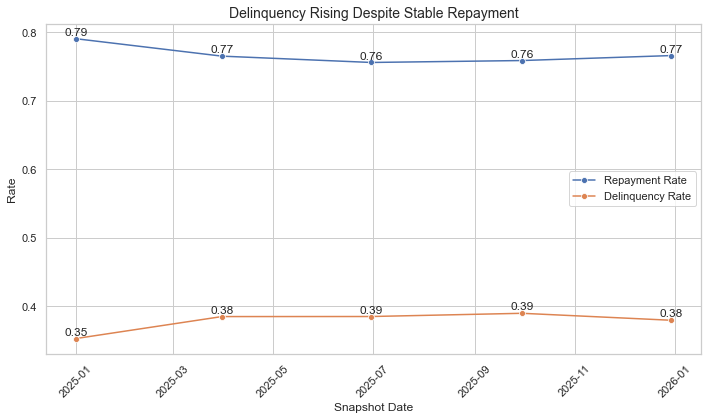

In [240]:

portfolio_trend = pd.DataFrame({
    "DATE": ["2025-01-01", "2025-03-31", "2025-06-30", "2025-09-30", "2025-12-30"],
    "repayment_rate": [0.790740, 0.765290, 0.756060, 0.758874, 0.766142],
    "delinquency_rate": [0.352882, 0.384978, 0.385069, 0.389765, 0.379568],
    "cash_efficiency": [3.138718, 3.334469, 3.420524, 3.536761, 3.577695]
})

# Convert DATE to datetime
portfolio_trend["DATE"] = pd.to_datetime(portfolio_trend["DATE"])

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

# Plot lines
sns.lineplot(data=portfolio_trend, x="DATE", y="repayment_rate", marker="o", label="Repayment Rate")
sns.lineplot(data=portfolio_trend, x="DATE", y="delinquency_rate", marker="o", label="Delinquency Rate")

# Titles and labels
plt.title("Delinquency Rising Despite Stable Repayment", fontsize=14)
plt.xlabel("Snapshot Date")
plt.ylabel("Rate")

# Rotate dates
plt.xticks(rotation=45)

# Annotate values
for i in range(len(portfolio_trend)):
    plt.text(portfolio_trend["DATE"][i],
             portfolio_trend["repayment_rate"][i] + 0.005,
             f"{portfolio_trend['repayment_rate'][i]:.2f}",
             ha='center')

    plt.text(portfolio_trend["DATE"][i],
             portfolio_trend["delinquency_rate"][i] + 0.005,
             f"{portfolio_trend['delinquency_rate'][i]:.2f}",
             ha='center')

plt.legend()
plt.tight_layout()

# Save image for slides
plt.savefig("portfolio_trend_final.png", dpi=300)

plt.show()

In [175]:
#Income performance metrics
income_segment = df_clean.groupby("income_band").agg(
    avg_income=("avg_monthly_income", "mean"),
    customer_count=("Loan Id", "count"),
    avg_cash=("CASH_PRICE", "mean"),
    avg_loan=("LOAN_PRICE", "mean")
).reset_index()

In [183]:
#Income risk proxy (optional but strong)
income_segment["loan_to_cash_ratio"] = (
    income_segment["avg_loan"] / income_segment["avg_cash"]
)




In [184]:
#PORTFOLIO AVERAGE (BASELINE)
portfolio_repayment_rate = (
    credit_data["TOTAL_PAID"].sum() /
    credit_data["TOTAL_DUE_TODAY"].sum()
)

portfolio_delinquency_rate = (
    credit_data["DAYS_PAST_DUE"] > 30
).mean()


In [185]:
#SEGMENT VS PORTFOLIO COMPARISON
income_segment["portfolio_repayment_rate"] = portfolio_repayment_rate
income_segment["portfolio_delinquency_rate"] = portfolio_delinquency_rate

income_segment

,income_band,avg_income,customer_count,avg_cash,avg_loan,portfolio_repayment_rate,portfolio_delinquency_rate,loan_to_cash_ratio
0,"10,000–19,999",15847.992760,294,28219.068027,50876.755102,0.723558,0.380542,1.802921
1,"100,000–149,999",123162.123018,1544,39479.440415,71009.608290,0.723558,0.380542,1.798648
2,"150,000+",463269.171800,14552,45276.810198,76843.974780,0.723558,0.380542,1.697204
3,"20,000–29,999",25110.527302,507,29691.110454,53703.969625,0.723558,0.380542,1.808756
4,"30,000–49,999",40096.776519,1283,34976.513640,63147.332034,0.723558,0.380542,1.805421
5,"5,000–9,999",7521.889875,77,27578.220779,49840.688312,0.723558,0.380542,1.807248
6,"50,000–99,999",73047.039623,2404,36689.016639,66314.931115,0.723558,0.380542,1.807487
7,"Below 5,000",2787.027126,31,34231.258065,62139.322581,0.723558,0.380542,1.815280


In [186]:
print("=== PORTFOLIO TREND ===")
print(portfolio_trend)

print("\n=== INCOME SEGMENT ANALYSIS ===")
print(income_segment)

print("\n=== PORTFOLIO BENCHMARKS ===")
print("Repayment Rate:", portfolio_repayment_rate)
print("Delinquency Rate:", portfolio_delinquency_rate)

=== PORTFOLIO TREND ===
        DATE  repayment_rate  delinquency_rate  cash_efficiency
0 2025-01-01        0.790740          0.352882         3.138718
1 2025-03-31        0.765290          0.384978         3.334469
2 2025-06-30        0.756060          0.385069         3.420524
3 2025-09-30        0.758874          0.389765         3.536761
4 2025-12-30        0.766142          0.379568         3.577695

=== INCOME SEGMENT ANALYSIS ===
       income_band     avg_income  customer_count      avg_cash      avg_loan  \
0    10,000–19,999   15847.992760             294  28219.068027  50876.755102   
1  100,000–149,999  123162.123018            1544  39479.440415  71009.608290   
2         150,000+  463269.171800           14552  45276.810198  76843.974780   
3    20,000–29,999   25110.527302             507  29691.110454  53703.969625   
4    30,000–49,999   40096.776519            1283  34976.513640  63147.332034   
5      5,000–9,999    7521.889875              77  27578.220779  49840.68

In [245]:
import pandas as pd

# Ensure DATE is datetime
portfolio_trend["DATE"] = pd.to_datetime(portfolio_trend["DATE"])

# Create cross join
income_segment["key"] = 1
portfolio_trend["key"] = 1

combined = pd.merge(portfolio_trend, income_segment, on="key").drop("key", axis=1)

# Create adjusted metric (proxy for risk)
combined["adjusted_repayment"] = combined["repayment_rate"] / combined["loan_to_cash_ratio"]

# Confirm it worked
print(combined.head())

        DATE  repayment_rate  delinquency_rate  cash_efficiency  \
0 2025-01-01         0.79074          0.352882         3.138718   
1 2025-01-01         0.79074          0.352882         3.138718   
2 2025-01-01         0.79074          0.352882         3.138718   
3 2025-01-01         0.79074          0.352882         3.138718   
4 2025-01-01         0.79074          0.352882         3.138718   

       income_band     avg_income  customer_count      avg_cash      avg_loan  \
0    10,000–19,999   15847.992760             294  28219.068027  50876.755102   
1  100,000–149,999  123162.123018            1544  39479.440415  71009.608290   
2         150,000+  463269.171800           14552  45276.810198  76843.974780   
3    20,000–29,999   25110.527302             507  29691.110454  53703.969625   
4    30,000–49,999   40096.776519            1283  34976.513640  63147.332034   

   portfolio_repayment_rate  portfolio_delinquency_rate  loan_to_cash_ratio  \
0                  0.723558    

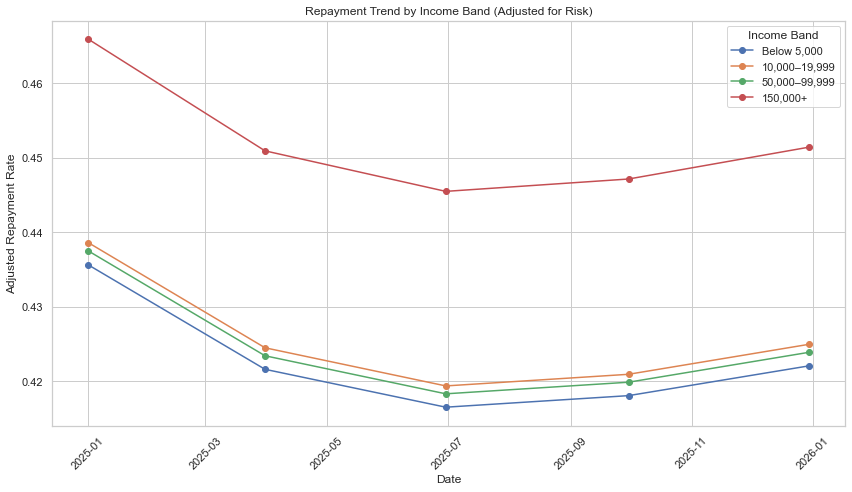

In [246]:

plt.figure(figsize=(12,7))

# Plot a few key segments (avoid clutter)
focus_bands = ["Below 5,000", "10,000–19,999", "50,000–99,999", "150,000+"]

for band in focus_bands:
    subset = combined[combined["income_band"] == band]
    plt.plot(subset["DATE"], subset["adjusted_repayment"], marker='o', label=band)

plt.title("Repayment Trend by Income Band (Adjusted for Risk)")
plt.xlabel("Date")
plt.ylabel("Adjusted Repayment Rate")
plt.xticks(rotation=45)
plt.legend(title="Income Band")

plt.tight_layout()
plt.savefig("income_vs_trend.png", dpi=300)
plt.show()

In [ ]:
Question 2: Credit Outcomes × Customer Experience (35%)
Using the NPS data, explore whether there is a relationship between credit performance (e.g. arrears,
default, account status) and customer satisfaction. Where do you see tension between collections
effectiveness and customer experience? Recommend one concrete action.

In [187]:
# PREP & MERGE DATA

credit_data.rename(columns={"LOAN_ID": "loan_id"}, inplace=True)

# Convert date fields
nps_clean["submitted_at"] = pd.to_datetime(nps_clean["submitted_at"])
credit_data["DATE"] = pd.to_datetime(credit_data["DATE"])

# Merge datasets
df_nps_credit = pd.merge(
    nps_clean,
    credit_data,
    on="loan_id",
    how="left"
)

In [188]:
#Delinquency flag
df_nps_credit["is_delinquent"] = (
    df_nps_credit["DAYS_PAST_DUE"] > 30
).astype(int)

In [189]:
#Severe delinquency (higher risk)
df_nps_credit["is_severely_delinquent"] = (
    df_nps_credit["DAYS_PAST_DUE"] > 60
).astype(int)

In [190]:
#Repayment rate
df_nps_credit["repayment_rate"] = (
    df_nps_credit["TOTAL_PAID"] /
    df_nps_credit["TOTAL_DUE_TODAY"]
)

In [191]:
#Account stress (balance burden)
df_nps_credit["balance_ratio"] = (
    df_nps_credit["BALANCE"] /
    df_nps_credit["TOTAL_DUE_TODAY"]
)


In [192]:
#Average credit metrics by NPS category
nps_vs_credit = df_nps_credit.groupby("nps_category").agg(
    avg_dpd=("DAYS_PAST_DUE", "mean"),
    delinquency_rate=("is_delinquent", "mean"),
    severe_delinquency=("is_severely_delinquent", "mean"),
    avg_repayment=("repayment_rate", "mean"),
    avg_balance_ratio=("balance_ratio", "mean"),
    count=("loan_id", "count")
).reset_index()

print(nps_vs_credit)

  nps_category    avg_dpd  delinquency_rate  severe_delinquency  \
0    Detractor  55.852301          0.254188            0.215868   
1      Passive  24.845495          0.136567            0.100693   
2     Promoter  27.066796          0.148738            0.117282   

   avg_repayment  avg_balance_ratio  count  
0       0.861005           1.371368   5193  
1       0.933037           1.396598   2453  
2       0.920759           1.385614   5150  


In [193]:
#NUMERICAL RELATIONSHIP (CORRELATION)
correlation = df_nps_credit[[
    "nps_score",
    "DAYS_PAST_DUE",
    "repayment_rate",
    "balance_ratio"
]].corr()

print(correlation)

                DAYS_PAST_DUE  repayment_rate  balance_ratio
DAYS_PAST_DUE        1.000000       -0.734267      -0.133101
repayment_rate      -0.734267        1.000000       0.077365
balance_ratio       -0.133101        0.077365       1.000000


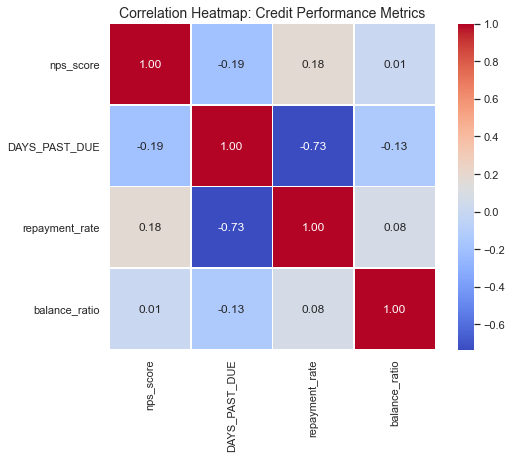

In [247]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select variables
corr_df = df_nps_credit[[
    "nps_score",
    "DAYS_PAST_DUE",
    "repayment_rate",
    "balance_ratio"
]]

# Compute correlation matrix
correlation = corr_df.corr()

# Set figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(
    correlation,
    annot=True,          # show values
    cmap="coolwarm",     # color palette
    fmt=".2f",           # 2 decimal places
    linewidths=0.5,
    square=True
)

# Title
plt.title("Correlation Heatmap: Credit Performance Metrics", fontsize=14)

# Save image safely
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

In [ ]:
EXPERIENCE PAIN POINTS (TENSION ANALYSIS)

In [195]:
detractor_analysis = df_nps_credit.groupby("nps_category").agg(
    avg_dpd=("DAYS_PAST_DUE", "mean"),
    delinquency_rate=("is_delinquent", "mean"),
    repayment_rate=("repayment_rate", "mean")
).reset_index()

print(detractor_analysis)

  nps_category    avg_dpd  delinquency_rate  repayment_rate
0    Detractor  55.852301          0.254188        0.861005
1      Passive  24.845495          0.136567        0.933037
2     Promoter  27.066796          0.148738        0.920759


In [201]:
df_nps_credit["nps_score"] = pd.to_numeric(
    df_nps_credit["nps_score"], errors="coerce"
)

In [200]:
df_nps_credit["is_delinquent"] = df_nps_credit["is_delinquent"].astype(float)

In [199]:
support_vs_nps = df_nps_credit.groupby(
    "have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?"
).agg(
    avg_nps=("nps_score", "mean"),
    delinquency_rate=("is_delinquent", "mean")
).reset_index()

print(support_vs_nps)

  have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?  \
0                                                 No                                            
1          No, I have never looked for customer care                                            
2                                            Unknown                                            
3                                                Yes                                            

    avg_nps  delinquency_rate  
0  7.846853          0.158361  
1  7.325887          0.102497  
2  6.273547          0.212500  
3  4.656716          0.226923  


In [ ]:
Question 3: Data Quality & Recommendations (25%)
What limitations did you encounter in the data? What is missing, inconsistent, or ambiguous? Propose
2–3 specific improvements to how MoPhones captures or structures credit data to make ongoing
monitoring easier.

In [ ]:
#Data Before Clean

In [227]:
credit_data.head()
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71456 entries, 0 to 71455
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   loan_id                          71456 non-null  object        
 1   DATE                             71456 non-null  datetime64[ns]
 2   CUSTOMER_AGE                     71456 non-null  int64         
 3   TOTAL_PAID                       71456 non-null  int64         
 4   TOTAL_DUE_TODAY                  71428 non-null  float64       
 5   BALANCE                          71448 non-null  float64       
 6   DAYS_PAST_DUE                    71456 non-null  int64         
 7   CLOSING_BALANCE                  71448 non-null  float64       
 8   ADVANCE                          71456 non-null  float64       
 9   BALANCE_DUE_TO_DATE              71428 non-null  float64       
 10  ARREARS                          71456 non-null  float64  

In [232]:
credit_data.describe().T

,count,mean,std,min,25%,50%,75%,max
CUSTOMER_AGE,71456.0,295.006172,212.042127,0.000000,118.000000,259.000000,440.000000,1056.000000
TOTAL_PAID,71456.0,36438.008453,27685.899248,-20499.000000,14919.000000,29799.500000,49342.250000,222159.000000
TOTAL_DUE_TODAY,71428.0,50379.246626,30335.827589,3099.000000,28586.500000,45539.000000,67819.000000,334219.000000
BALANCE,71448.0,34085.654487,28841.245947,-81294.000000,8000.000000,32350.000000,51652.500000,205019.000000
DAYS_PAST_DUE,71456.0,108.602301,179.766169,0.000000,0.000000,0.000000,170.000000,1048.000000
CLOSING_BALANCE,71448.0,30503.744597,30039.850078,-1.000000,0.000000,28600.000000,49760.000000,205019.000000
ADVANCE,71456.0,442.276469,2651.785645,0.000000,0.000000,0.000000,0.000000,91254.000000
BALANCE_DUE_TO_DATE,71428.0,-13708.343073,23165.043061,-205019.000000,-23380.000000,-600.000000,0.000000,91254.000000
ARREARS,71456.0,14145.247934,22736.274722,0.000000,0.000000,600.000000,23372.500000,205019.000000
PAYMENT,71456.0,74.857997,699.693919,0.000000,0.000000,0.000000,0.000000,47499.000000


In [228]:
nps.head()
nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4129 entries, 0 to 4128
Data columns (total 17 columns):
 #   Column                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                 --------------  -----  
 0   Submission ID                                                                                                          4129 non-null   object 
 1   Respondent ID                                                                                                          4129 non-null   object 
 2   Submitted at                                                                                                           4129 non-null   object 
 3   Loan Id                                                                                                                4129 non-null   object 
 4   

In [229]:
nps.describe()

,"Using a scale from 0 (not likely) to 10 (very likely), how likely are you to recommend MoPhones to friends or family?"
count,3985.000000
mean,6.779172
std,3.386783
min,0.000000
25%,5.000000
50%,8.000000
75%,10.000000
max,10.000000
